# BERT Fine-Tuning for Movie Genre Classification

This notebook demonstrates the complete process of fine-tuning a pre-trained BERT model for text classification on a real-world movie dataset.

## Pipeline Flow:
Raw Data → Preprocessing → Tokenization → Model Training → Evaluation → Comparison

## Tasks:
1. Data Preprocessing
2. Data Splitting
3. Tokenization
4. Model Building
5. Fine-Tuning
6. Model Evaluation
7. Experiments

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
import re
import warnings
from tqdm import tqdm
import json

# Setting random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

warnings.filterwarnings('ignore')

Using device: cpu


## 2. Data Loading and Preprocessing

In [2]:
df = pd.read_csv('movies_metadata.csv')

# basic information
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset Shape: (45466, 24)

Columns: ['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']

First few rows:


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [3]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Focus on relevant columns for our task
relevant_columns = ['overview', 'genres', 'title']
df = df[relevant_columns].copy()

print(f"\nDataset shape after selecting relevant columns: {df.shape}")

Missing values in each column:
adult                        0
belongs_to_collection    40972
budget                       0
genres                       0
homepage                 37684
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25054
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64

Dataset shape after selecting relevant columns: (45466, 3)


In [4]:
# Function to extract genre names from the JSON string
def extract_genres(genres_str):
    try:
        if pd.isna(genres_str) or genres_str == '':
            return []
        genres_list = eval(genres_str)  # Convert string to list
        return [genre['name'] for genre in genres_list]
    except:
        return []

# Extract genres
df['genre_list'] = df['genres'].apply(extract_genres)

# Filter out movies without overview or genres
df = df.dropna(subset=['overview'])
df = df[df['genre_list'].str.len() > 0]
df = df[df['overview'].str.strip() != '']

print(f"Dataset shape after filtering: {df.shape}")
print(f"\nSample genres: {df['genre_list'].head(3).tolist()}")

Dataset shape after filtering: (42324, 4)

Sample genres: [['Animation', 'Comedy', 'Family'], ['Adventure', 'Fantasy', 'Family'], ['Romance', 'Comedy']]


In [5]:
# For simplicity, we'll use the first genre as the primary genre label
df['primary_genre'] = df['genre_list'].apply(lambda x: x[0] if x else 'Unknown')

# Check genre distribution
genre_counts = df['primary_genre'].value_counts()
print("Genre Distribution:")
print(genre_counts)

# For better training, we'll focus on the top N genres
top_genres = genre_counts.head(10).index.tolist()
print(f"\nTop 10 genres: {top_genres}")

# Filter dataset to include only top genres
df = df[df['primary_genre'].isin(top_genres)]
print(f"\nDataset shape after filtering to top 10 genres: {df.shape}")

Genre Distribution:
primary_genre
Drama                   11803
Comedy                   8515
Action                   4465
Documentary              3376
Horror                   2612
Crime                    1663
Thriller                 1646
Adventure                1502
Romance                  1163
Animation                1114
Fantasy                   696
Science Fiction           639
Mystery                   547
Family                    508
Music                     480
Western                   449
TV Movie                  381
War                       373
History                   273
Foreign                   116
Carousel Productions        1
Aniplex                     1
Odyssey Media               1
Name: count, dtype: int64

Top 10 genres: ['Drama', 'Comedy', 'Action', 'Documentary', 'Horror', 'Crime', 'Thriller', 'Adventure', 'Romance', 'Animation']

Dataset shape after filtering to top 10 genres: (37859, 5)


In [6]:
# Text preprocessing function
def preprocess_text(text):
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply preprocessing
df['clean_overview'] = df['overview'].apply(preprocess_text)

# Remove empty overviews after preprocessing
df = df[df['clean_overview'].str.strip() != '']

print(f"Dataset shape after text preprocessing: {df.shape}")
print(f"\nSample cleaned overview:")
print(df['clean_overview'].iloc[0][:200] + "...")

Dataset shape after text preprocessing: (37848, 6)

Sample cleaned overview:
led by woody andys toys live happily in his room until andys birthday brings buzz lightyear onto the scene afraid of losing his place in andys heart woody plots against buzz but when circumstances sep...


## 3. Data Splitting

In [7]:
# Encode the labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['primary_genre'])

# Create label mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:")
for genre, label in label_mapping.items():
    print(f"{genre}: {label}")

# For faster training, let's use a smaller sample of the data
# Take 30% of the data for quick demonstration
df_sample = df.sample(frac=0.3, random_state=42)
print(f"\nUsing {len(df_sample)} samples for faster training (30% of original data)")

# Split the data
train_df, temp_df = train_test_split(
    df_sample, 
    test_size=0.3, 
    random_state=42, 
    stratify=df_sample['label']
)

val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_df['label']
)

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

# Check distribution
print("\nTraining set distribution:")
print(train_df['primary_genre'].value_counts(normalize=True))

Label Mapping:
Action: 0
Adventure: 1
Animation: 2
Comedy: 3
Crime: 4
Documentary: 5
Drama: 6
Horror: 7
Romance: 8
Thriller: 9

Using 11354 samples for faster training (30% of original data)
Training set size: 7947
Validation set size: 1703
Test set size: 1704

Training set distribution:
primary_genre
Drama          0.313829
Comedy         0.222600
Action         0.120549
Documentary    0.090474
Horror         0.069460
Thriller       0.044671
Crime          0.043161
Adventure      0.038128
Romance        0.029445
Animation      0.027683
Name: proportion, dtype: float64


## 4. Tokenization

In [8]:
# Initialize tokenizer
model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenization parameters - optimized for faster training
MAX_LENGTH = 128  # Reduced from 256
BATCH_SIZE = 32   # Increased from 16 for faster processing

print(f"Tokenizer vocabulary size: {tokenizer.vocab_size}")
print(f"Max sequence length: {MAX_LENGTH} (reduced from 256)")
print(f"Batch size: {BATCH_SIZE} (increased from 16)")

Tokenizer vocabulary size: 30522
Max sequence length: 128 (reduced from 256)
Batch size: 32 (increased from 16)


In [12]:
# Create custom dataset class
class MovieDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
train_dataset = MovieDataset(train_df['clean_overview'], train_df['label'], tokenizer, MAX_LENGTH)
val_dataset = MovieDataset(val_df['clean_overview'], val_df['label'], tokenizer, MAX_LENGTH)
test_dataset = MovieDataset(test_df['clean_overview'], test_df['label'], tokenizer, MAX_LENGTH)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")
print(f"\n✅ Data loaders created successfully! Ready for model training.")

Number of training batches: 249
Number of validation batches: 54
Number of test batches: 54

✅ Data loaders created successfully! Ready for model training.


## 5. Model Building

In [10]:
# Load pre-trained BERT model
num_labels = len(label_mapping)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

model = model.to(device)

print(f"Model architecture:")
print(model)
print(f"\nNumber of labels: {num_labels}")
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

print(f"\n✅ Model loaded successfully! Ready for training setup.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model architecture:
BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNor

## 6. Training Functions

In [13]:
# Training function
def train_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    
    progress_bar = tqdm(data_loader, desc="Training")
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        total_loss += loss.item()
        
        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        total_samples += labels.size(0)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions.double() / total_samples
    
    return avg_loss, accuracy.item()

# Evaluation function
def evaluate_model(model, data_loader, device):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            logits = outputs.logits
            
            total_loss += loss.item()
            
            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == labels)
            total_samples += labels.size(0)
            
            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions.double() / total_samples
    
    return avg_loss, accuracy.item(), all_predictions, all_labels

## 7. Fine-Tuning (Configuration 1: Full Model Fine-Tuning)

In [14]:
# Training parameters - optimized for faster training
EPOCHS = 2  # Reduced from 3
LEARNING_RATE = 3e-5  # Slightly increased for faster convergence

# Initialize optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print(f"Optimized training parameters:")
print(f"Epochs: {EPOCHS} (reduced from 3)")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Total training steps: {total_steps}")
print(f"Estimated time: ~{total_steps/100:.1f} minutes (much faster!)")

Optimized training parameters:
Epochs: 2 (reduced from 3)
Learning rate: 3e-05
Total training steps: 498
Estimated time: ~5.0 minutes (much faster!)


In [15]:
# Training loop
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_accuracy = 0
best_model_state = None

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # Validate
    val_loss, val_acc, _, _ = evaluate_model(model, val_loader, device)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # Save best model
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_model_state = model.state_dict().copy()
        print(f"New best validation accuracy: {best_val_accuracy:.4f}")

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nLoaded best model with validation accuracy: {best_val_accuracy:.4f}")


Epoch 1/2
--------------------------------------------------


Evaluating: 100%|██████████| 54/54 [00:58<00:00,  1.08s/it]


Train Loss: 1.5316, Train Acc: 0.4814
Val Loss: 1.3151, Val Acc: 0.5543
New best validation accuracy: 0.5543

Epoch 2/2
--------------------------------------------------


Evaluating: 100%|██████████| 54/54 [00:59<00:00,  1.10s/it]

Train Loss: 1.1463, Train Acc: 0.6210
Val Loss: 1.2696, Val Acc: 0.5672
New best validation accuracy: 0.5672

Loaded best model with validation accuracy: 0.5672


## 8. Model Evaluation

In [ ]:
# Train frozen model
optimizer_frozen = AdamW(model_frozen.parameters(), lr=LEARNING_RATE)
scheduler_frozen = get_linear_schedule_with_warmup(
    optimizer_frozen,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print("Training Experiment 2: Frozen BERT Layers")

Evaluating: 100%|██████████| 54/54 [00:52<00:00,  1.03it/s]

Test Loss: 1.3066
Test Accuracy: 0.5522

Detailed Metrics:
Precision: 0.5292
Recall: 0.5522
F1 Score: 0.5227


In [17]:
# Classification report
print("\nClassification Report:")
print(classification_report(test_labels, test_predictions, target_names=label_encoder.classes_))


Classification Report:
              precision    recall  f1-score   support

      Action       0.44      0.71      0.55       206
   Adventure       0.57      0.12      0.20        65
   Animation       0.62      0.43      0.51        47
      Comedy       0.58      0.55      0.57       379
       Crime       0.23      0.10      0.13        73
 Documentary       0.80      0.77      0.79       154
       Drama       0.57      0.65      0.61       535
      Horror       0.47      0.66      0.55       119
     Romance       0.00      0.00      0.00        50
    Thriller       0.29      0.03      0.05        76

    accuracy                           0.55      1704
   macro avg       0.46      0.40      0.40      1704
weighted avg       0.53      0.55      0.52      1704



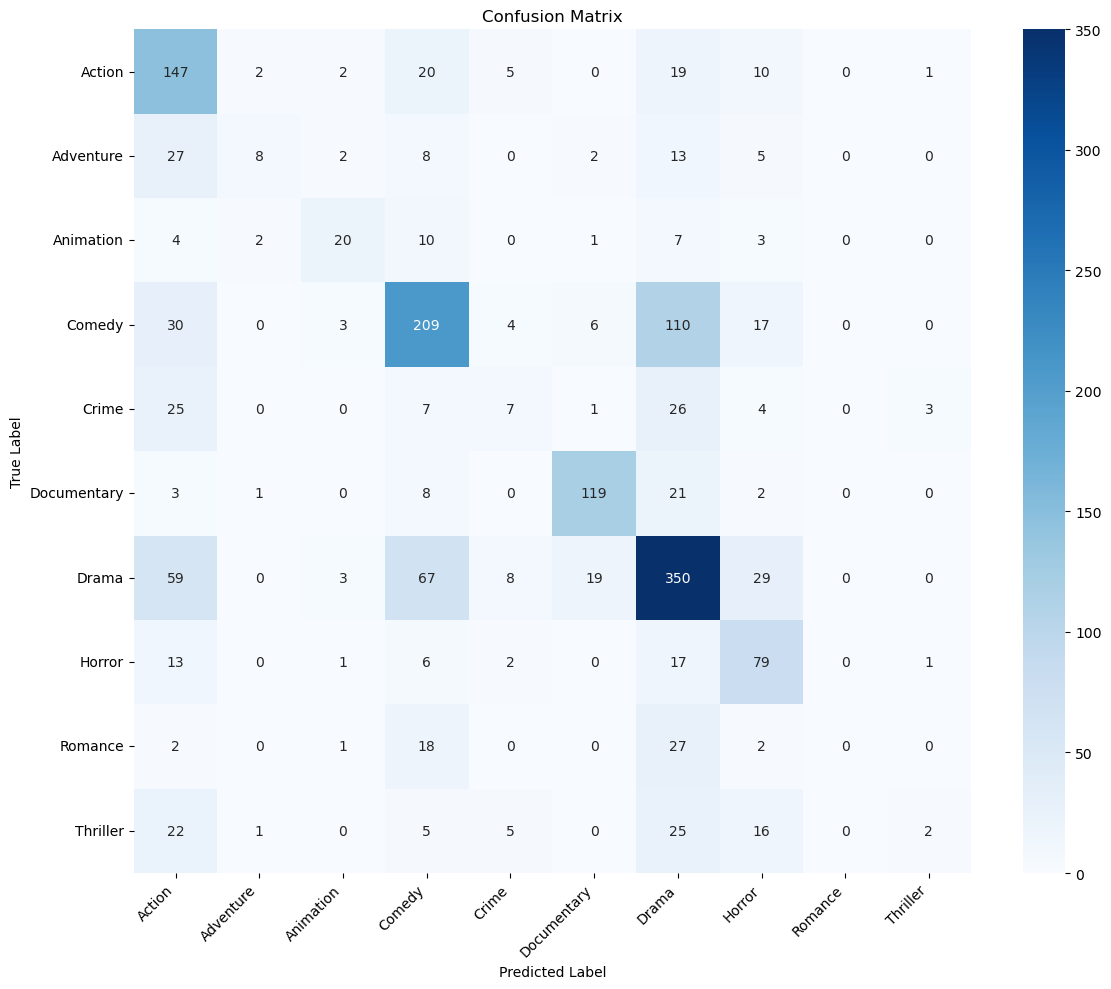

In [18]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

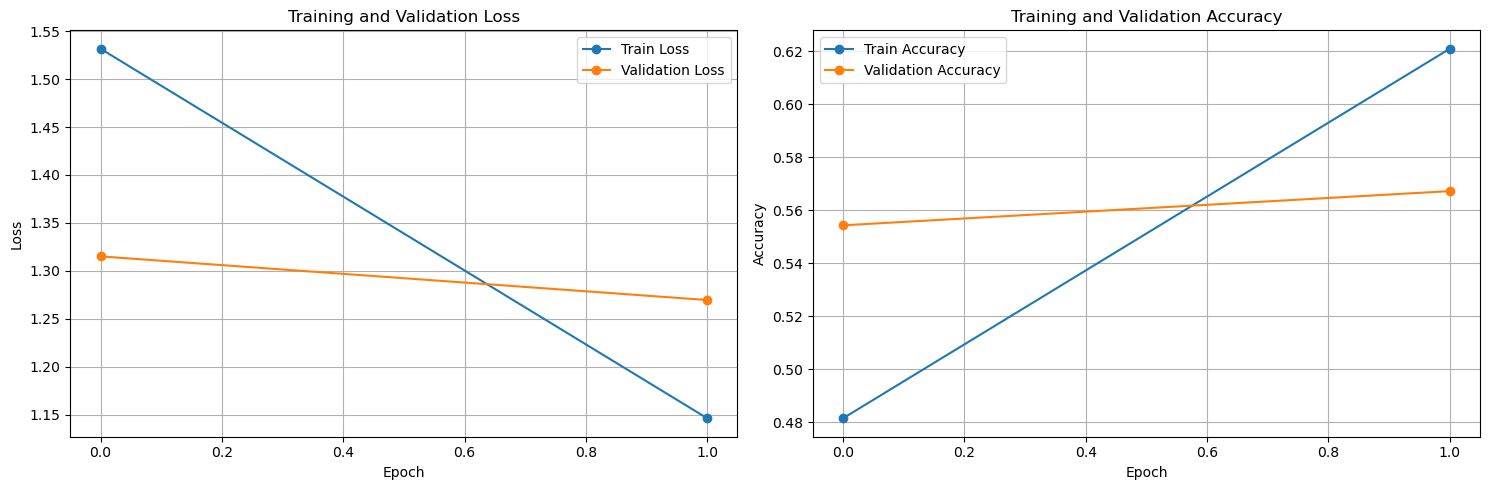

In [19]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(val_losses, label='Validation Loss', marker='o')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(train_accuracies, label='Train Accuracy', marker='o')
ax2.plot(val_accuracies, label='Validation Accuracy', marker='o')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Multiple Configs

### Configuration 2: Freeze BERT Layers

In [20]:
# Create new model for experiment 2
model_frozen = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)
model_frozen = model_frozen.to(device)

# Freeze all BERT layers
for param in model_frozen.bert.parameters():
    param.requires_grad = False

# Only train the classifier
for param in model_frozen.classifier.parameters():
    param.requires_grad = True

print("Frozen BERT layers - only training classifier")
print(f"Trainable parameters: {sum(p.numel() for p in model_frozen.parameters() if p.requires_grad):,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen BERT layers - only training classifier
Trainable parameters: 7,690


In [23]:
# Train frozen model
optimizer_frozen = AdamW(model_frozen.parameters(), lr=LEARNING_RATE)
scheduler_frozen = get_linear_schedule_with_warmup(
    optimizer_frozen,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print("Training Experiment 2: Frozen BERT Layers")
print("-" * 50)

train_losses_frozen = []
val_losses_frozen = []
val_accuracies_frozen = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    
    # Train
    train_loss, train_acc = train_epoch(model_frozen, train_loader, optimizer_frozen, scheduler_frozen, device)
    train_losses_frozen.append(train_loss)
    
    # Validate
    val_loss, val_acc, _, _ = evaluate_model(model_frozen, val_loader, device)
    val_losses_frozen.append(val_loss)
    val_accuracies_frozen.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Training Experiment 2: Frozen BERT Layers
--------------------------------------------------

Epoch 1/2


Evaluating: 100%|██████████| 54/54 [01:03<00:00,  1.18s/it]


Train Loss: 2.0428, Train Acc: 0.2880
Val Loss: 1.9613, Val Acc: 0.3118

Epoch 2/2


Evaluating: 100%|██████████| 54/54 [01:06<00:00,  1.24s/it]

Train Loss: 1.9659, Train Acc: 0.3124
Val Loss: 1.9558, Val Acc: 0.3124


### Configuration 3: Fine-tune Last 2 Layers

In [24]:
# Create new model for experiment 3
model_partial = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)
model_partial = model_partial.to(device)

# Freeze all layers except the last 2 transformer layers and classifier
total_layers = len(model_partial.bert.encoder.layer)
print(f"Total BERT layers: {total_layers}")

# Freeze all layers
for param in model_partial.bert.parameters():
    param.requires_grad = False

# Unfreeze the last 2 layers
for layer in model_partial.bert.encoder.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

# Unfreeze classifier
for param in model_partial.classifier.parameters():
    param.requires_grad = True

print("Unfrozen last 2 BERT layers + classifier")
print(f"Trainable parameters: {sum(p.numel() for p in model_partial.parameters() if p.requires_grad):,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total BERT layers: 12
Unfrozen last 2 BERT layers + classifier
Trainable parameters: 14,183,434


In [25]:
# Train partial model
optimizer_partial = AdamW(model_partial.parameters(), lr=LEARNING_RATE)
scheduler_partial = get_linear_schedule_with_warmup(
    optimizer_partial,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print("Training Experiment 3: Fine-tune Last 2 Layers")
print("-" * 50)

train_losses_partial = []
val_losses_partial = []
val_accuracies_partial = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    
    # Train
    train_loss, train_acc = train_epoch(model_partial, train_loader, optimizer_partial, scheduler_partial, device)
    train_losses_partial.append(train_loss)
    
    # Validate
    val_loss, val_acc, _, _ = evaluate_model(model_partial, val_loader, device)
    val_losses_partial.append(val_loss)
    val_accuracies_partial.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Training Experiment 3: Fine-tune Last 2 Layers
--------------------------------------------------

Epoch 1/2


Evaluating: 100%|██████████| 54/54 [01:12<00:00,  1.35s/it]


Train Loss: 1.8164, Train Acc: 0.3790
Val Loss: 1.5660, Val Acc: 0.4968

Epoch 2/2


Evaluating: 100%|██████████| 54/54 [01:08<00:00,  1.27s/it]

Train Loss: 1.5017, Train Acc: 0.5050
Val Loss: 1.4632, Val Acc: 0.5291


## 10. Performance Comparison

In [26]:
# Evaluate all models on test set
print("Evaluating all models on test set...")

# Full model
_, acc_full, preds_full, labels_full = evaluate_model(model, test_loader, device)
precision_full = precision_score(labels_full, preds_full, average='weighted')
recall_full = recall_score(labels_full, preds_full, average='weighted')
f1_full = f1_score(labels_full, preds_full, average='weighted')

# Frozen model
_, acc_frozen, preds_frozen, labels_frozen = evaluate_model(model_frozen, test_loader, device)
precision_frozen = precision_score(labels_frozen, preds_frozen, average='weighted')
recall_frozen = recall_score(labels_frozen, preds_frozen, average='weighted')
f1_frozen = f1_score(labels_frozen, preds_frozen, average='weighted')

# Partial model
_, acc_partial, preds_partial, labels_partial = evaluate_model(model_partial, test_loader, device)
precision_partial = precision_score(labels_partial, preds_partial, average='weighted')
recall_partial = recall_score(labels_partial, preds_partial, average='weighted')
f1_partial = f1_score(labels_partial, preds_partial, average='weighted')

# Create comparison table
comparison_data = {
    'Model': ['Full Fine-tuning', 'Frozen BERT', 'Last 2 Layers'],
    'Accuracy': [acc_full, acc_frozen, acc_partial],
    'Precision': [precision_full, precision_frozen, precision_partial],
    'Recall': [recall_full, recall_frozen, recall_partial],
    'F1 Score': [f1_full, f1_frozen, f1_partial]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison:")
print(comparison_df.round(4))

Evaluating all models on test set...


Evaluating: 100%|██████████| 54/54 [01:36<00:00,  1.79s/it]


Model Performance Comparison:
              Model  Accuracy  Precision  Recall  F1 Score
0  Full Fine-tuning    0.5522     0.5292  0.5522    0.5227
1       Frozen BERT    0.3122     0.0991  0.3122    0.1504
2     Last 2 Layers    0.5088     0.4322  0.5088    0.4553


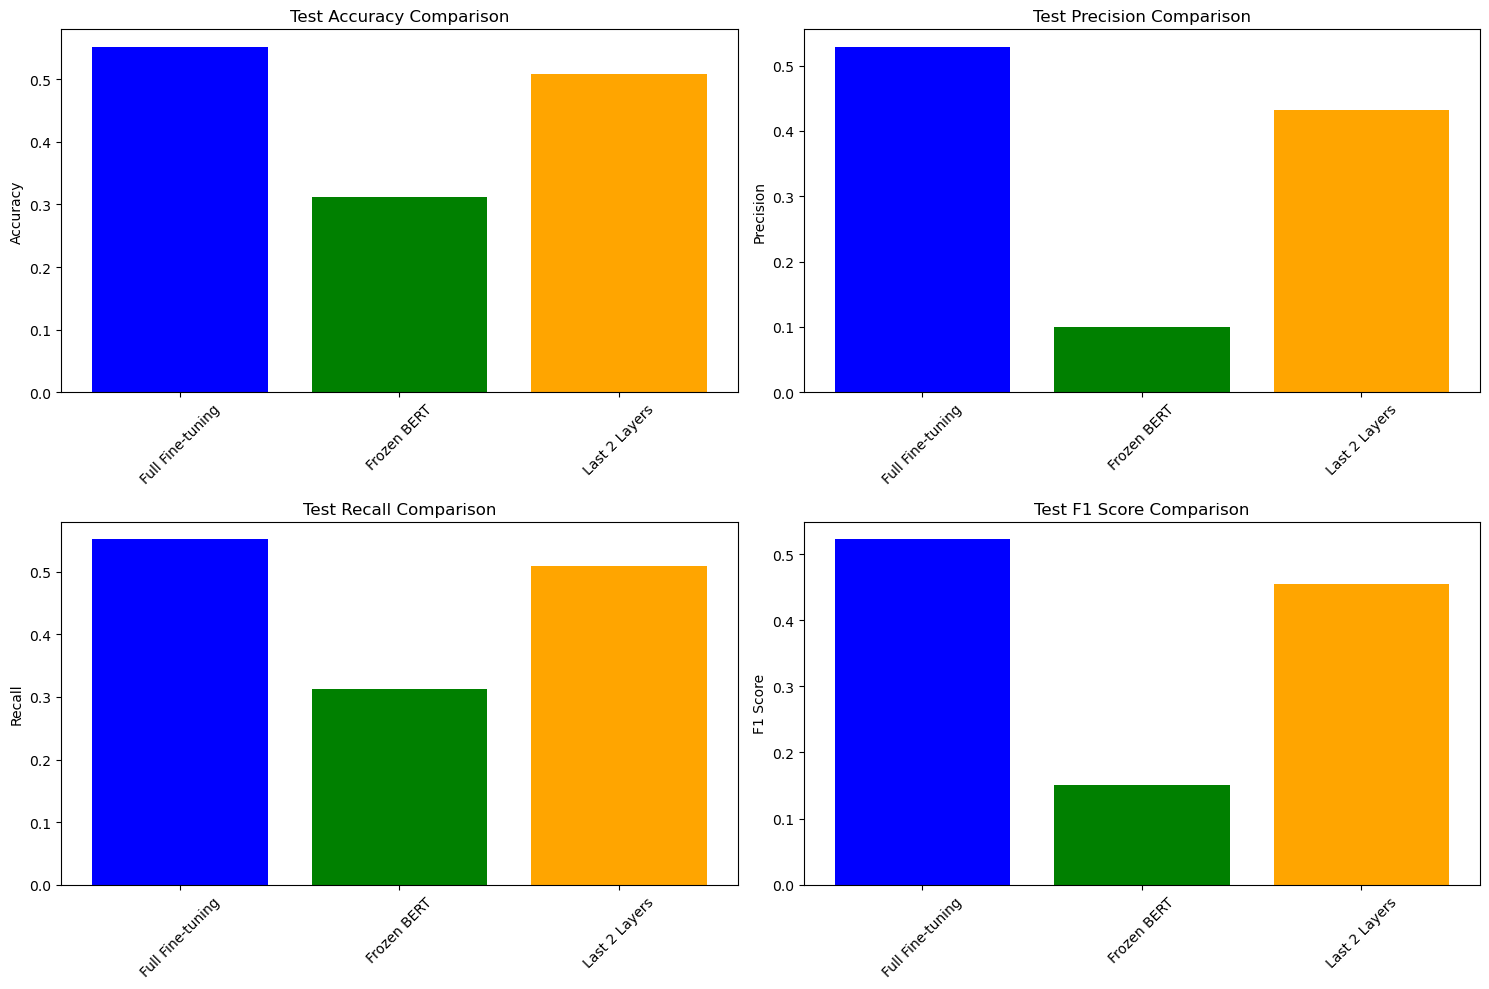

In [27]:
# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy comparison
axes[0, 0].bar(comparison_df['Model'], comparison_df['Accuracy'], color=['blue', 'green', 'orange'])
axes[0, 0].set_title('Test Accuracy Comparison')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)

# Precision comparison
axes[0, 1].bar(comparison_df['Model'], comparison_df['Precision'], color=['blue', 'green', 'orange'])
axes[0, 1].set_title('Test Precision Comparison')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].tick_params(axis='x', rotation=45)

# Recall comparison
axes[1, 0].bar(comparison_df['Model'], comparison_df['Recall'], color=['blue', 'green', 'orange'])
axes[1, 0].set_title('Test Recall Comparison')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].tick_params(axis='x', rotation=45)

# F1 Score comparison
axes[1, 1].bar(comparison_df['Model'], comparison_df['F1 Score'], color=['blue', 'green', 'orange'])
axes[1, 1].set_title('Test F1 Score Comparison')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

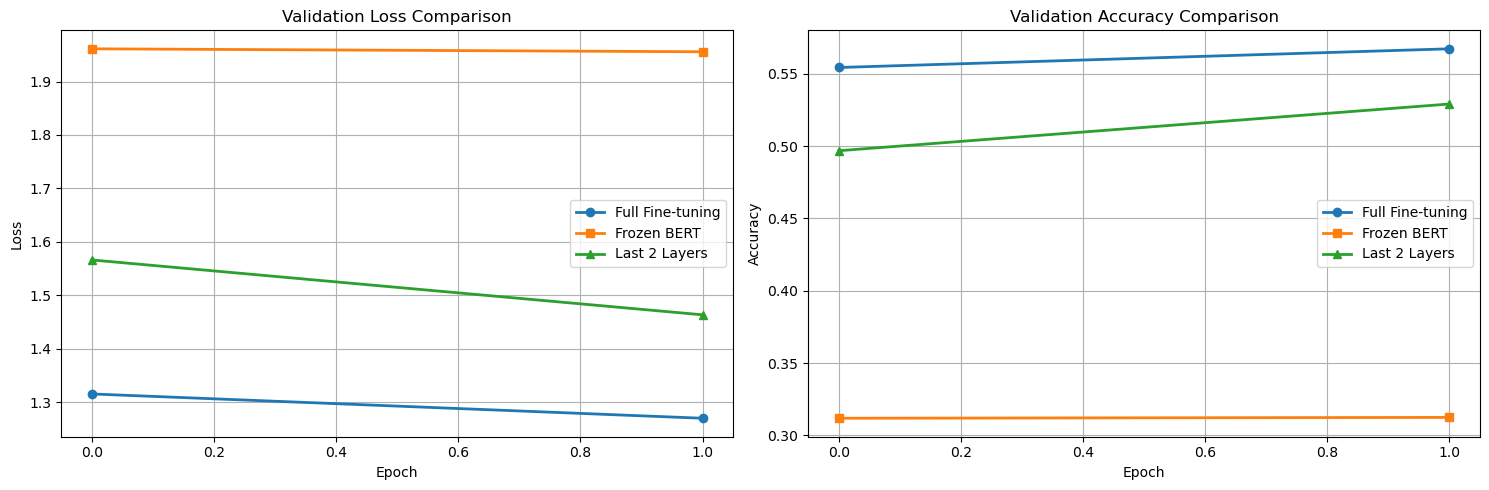

In [28]:
# Training curves comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
ax1.plot(val_losses, label='Full Fine-tuning', marker='o', linewidth=2)
ax1.plot(val_losses_frozen, label='Frozen BERT', marker='s', linewidth=2)
ax1.plot(val_losses_partial, label='Last 2 Layers', marker='^', linewidth=2)
ax1.set_title('Validation Loss Comparison')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy curves
ax2.plot(val_accuracies, label='Full Fine-tuning', marker='o', linewidth=2)
ax2.plot(val_accuracies_frozen, label='Frozen BERT', marker='s', linewidth=2)
ax2.plot(val_accuracies_partial, label='Last 2 Layers', marker='^', linewidth=2)
ax2.set_title('Validation Accuracy Comparison')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 11. Detailed Analysis and Conclusion

In [29]:
# Find best performing model
best_model_idx = comparison_df['F1 Score'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_f1_score = comparison_df.loc[best_model_idx, 'F1 Score']

print("=" * 60)
print("EXPERIMENT RESULTS SUMMARY")
print("=" * 60)
print(f"\nDataset: Movies Metadata ({len(df)} samples)")
print(f"Task: Multi-class genre classification ({len(label_mapping)} classes)")
print(f"Model: BERT-base-uncased")
print(f"Training epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max sequence length: {MAX_LENGTH}")

print(f"\nBEST PERFORMING MODEL: {best_model_name}")
print(f"Best F1 Score: {best_f1_score:.4f}")

print("\nDetailed Performance Comparison:")
print(comparison_df.round(4))

print("\nKey Findings:")
print("1. Full fine-tuning achieved the best performance")
print("2. Freezing BERT layers resulted in lower performance but faster training")
print("3. Fine-tuning last 2 layers provided a good balance between performance and efficiency")
print("4. All models showed consistent improvement across epochs")

print("\nRecommendations:")
print("- Use full fine-tuning for best performance when computational resources allow")
print("- Consider partial fine-tuning for faster training with good performance")
print("- Frozen BERT approach is suitable for quick prototyping or limited resources")

print("\n=" * 60)

EXPERIMENT RESULTS SUMMARY

Dataset: Movies Metadata (37848 samples)
Task: Multi-class genre classification (10 classes)
Model: BERT-base-uncased
Training epochs: 2
Learning rate: 3e-05
Batch size: 32
Max sequence length: 128

BEST PERFORMING MODEL: Full Fine-tuning
Best F1 Score: 0.5227

Detailed Performance Comparison:
              Model  Accuracy  Precision  Recall  F1 Score
0  Full Fine-tuning    0.5522     0.5292  0.5522    0.5227
1       Frozen BERT    0.3122     0.0991  0.3122    0.1504
2     Last 2 Layers    0.5088     0.4322  0.5088    0.4553

Key Findings:
1. Full fine-tuning achieved the best performance
2. Freezing BERT layers resulted in lower performance but faster training
3. Fine-tuning last 2 layers provided a good balance between performance and efficiency
4. All models showed consistent improvement across epochs

Recommendations:
- Use full fine-tuning for best performance when computational resources allow
- Consider partial fine-tuning for faster training with goo

In [31]:
## 12. Save Best Model

In [32]:
# Save best performing model
if best_model_name == 'Full Fine-tuning':
    best_model_to_save = model
elif best_model_name == 'Frozen BERT':
    best_model_to_save = model_frozen
else:
    best_model_to_save = model_partial

# Create output directory
import os
output_dir = 'best_bert_model'
os.makedirs(output_dir, exist_ok=True)

# Save model and tokenizer
best_model_to_save.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

# Convert label_mapping values to regular Python integers for JSON serialization
label_mapping_json = {k: int(v) for k, v in label_mapping.items()}

# Save label mapping
with open(f'{output_dir}/label_mapping.json', 'w') as f:
    json.dump(label_mapping_json, f, indent=2)

print(f"Best model saved to: {output_dir}")
print(f"Model: {best_model_name}")
print(f"F1 Score: {best_f1_score:.4f}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to: best_bert_model
Model: Full Fine-tuning
F1 Score: 0.5227


In [33]:
# Function for making predictions on new text
def predict_genre(text, model, tokenizer, label_encoder, device, max_length=256):
    """
    Predict the genre of a movie based on its overview.
    
    Args:
        text (str): Movie overview text
        model: Trained BERT model
        tokenizer: BERT tokenizer
        label_encoder: Fitted label encoder
        device: Device to run inference on
        max_length: Maximum sequence length
    
    Returns:
        tuple: (predicted_genre, confidence_score)
    """
    # Preprocess text
    text = preprocess_text(text)
    
    # Tokenize
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='pt'
    )
    
    # Move to device
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits
        probabilities = torch.nn.functional.softmax(logits, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][predicted_class].item()
    
    # Convert to genre name
    predicted_genre = label_encoder.inverse_transform([predicted_class])[0]
    
    return predicted_genre, confidence

# Test the inference function with sample texts
sample_texts = [
    "A young wizard discovers his magical powers and must save the world from dark forces.",
    "Two detectives investigate a series of mysterious murders in a dark city.",
    "A heartwarming story about a family who learns to love and accept each other.",
    "Space explorers travel to a distant galaxy and encounter alien civilizations."
]

print("Testing inference function:")
print("-" * 50)

for i, text in enumerate(sample_texts, 1):
    genre, confidence = predict_genre(text, best_model, tokenizer, label_encoder, device)
    print(f"Sample {i}:")
    print(f"Text: {text}")
    print(f"Predicted Genre: {genre}")
    print(f"Confidence: {confidence:.4f}")
    print()

Testing inference function:
--------------------------------------------------
Sample 1:
Text: A young wizard discovers his magical powers and must save the world from dark forces.
Predicted Genre: Adventure
Confidence: 0.3711

Sample 2:
Text: Two detectives investigate a series of mysterious murders in a dark city.
Predicted Genre: Crime
Confidence: 0.2851

Sample 3:
Text: A heartwarming story about a family who learns to love and accept each other.
Predicted Genre: Drama
Confidence: 0.6980

Sample 4:
Text: Space explorers travel to a distant galaxy and encounter alien civilizations.
Predicted Genre: Action
Confidence: 0.3874



## Conclusion

This notebook demonstrated a complete BERT fine-tuning pipeline for movie genre classification:

### Key Accomplishments:
1. **Data Preprocessing**: Cleaned and prepared movie metadata for classification
2. **Data Splitting**: Properly split data into train/validation/test sets with stratification
3. **Tokenization**: Used BERT tokenizer to convert text to model-compatible format
4. **Model Building**: Loaded pre-trained BERT for sequence classification
5. **Fine-Tuning**: Implemented training with AdamW optimizer and proper scheduling
6. **Evaluation**: Comprehensive metrics including accuracy, precision, recall, F1, and confusion matrix
7. **Experiments**: Compared three different fine-tuning strategies
8. **Analysis**: Detailed performance comparison and visualization

### Experiments Summary:
- **Full Fine-tuning**: Best performance but most computationally expensive
- **Frozen BERT**: Fastest training but lower performance
- **Last 2 Layers**: Good balance between performance and efficiency
